<a href="https://colab.research.google.com/github/silmucci/Computer_graphics/blob/main/Progetto_SII_Rilevamento_Danni_Auto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Progetto SII

Per ogni immagine vengono mostrate:

- una descrizione del danno;
- la spiegazione di come sono stati selezionati i casi simili;
- la raccomandazione principale e le possibili alternative;
- le condizioni che possono cambiare la scelta dell'intervento;
- le fonti Web consultate;
- i dati tecnici in sezioni espandibili;
- un report HTML salvato nella cartella dell'analisi.

In [1]:
# ============================================================
# 1. Installazione dipendenze e import
# ============================================================

!pip install -q ultralytics scikit-learn tavily-python

from pathlib import Path
from datetime import datetime, timezone
from collections import defaultdict
import base64
import hashlib
import html as html_lib
import json
import os
import re
import zipfile

import numpy as np
import pandas as pd
import torch

from google.colab import drive
from IPython.display import display, Image, HTML
from PIL import Image as PILImage
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tavily import TavilyClient
from ultralytics import YOLO

try:
    drive.mount('/content/drive')
except Exception as e:
    print("Drive già montato oppure mount non necessario:", e)

pd.set_option("display.max_colwidth", 180)
print("Configurazione completata.")
print("GPU disponibile:", torch.cuda.is_available())
print("Il ranking usa TF-IDF: non viene scaricato alcun modello linguistico.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Configurazione completata.
GPU disponibile: True
Il ranking usa TF-IDF: non viene scaricato alcun modello linguistico.


In [2]:
# ============================================================
# 2. Configurazione delle cartelle
# ============================================================

ZIP_PATH = Path(
    '/content/drive/MyDrive/car damage detected dataset CrackDentSctratch.v1-raw.yolov11.zip'
)
BASE_DATASET_DIR = Path('/content/car_damage_dataset')

DRIVE_PROJECT_DIR = Path('/content/drive/MyDrive/yolo_car_damage_models')
RUN_NAME = 'train_car_damage_yolo11n'
BEST_MODEL_PATH = DRIVE_PROJECT_DIR / RUN_NAME / 'weights' / 'best.pt'

OUTPUT_SII_DIR = Path('/content/drive/MyDrive/progetto_car_damage_SII_web')
OUTPUT_SII_DIR.mkdir(parents=True, exist_ok=True)

# Nuova cache: ogni risultato Web conserva la classe per cui è stato cercato.
CACHE_WEB_PATH = OUTPUT_SII_DIR / 'archivio_casi_web_per_classe_v3.csv'

CONF = 0.25
IMGSZ = 1024

USA_RICERCA_WEB = True
CERCA_WEB_SEMPRE = True
SOGLIA_RICERCA_WEB = 0.55

# Una chiamata Tavily separata per ogni classe rilevata.
MAX_RISULTATI_WEB_PER_CLASSE = 5
TOP_K_PER_CLASSE = 4
# Alias mantenuto per compatibilità con funzioni delle versioni precedenti.
TOP_K = TOP_K_PER_CLASSE

TAVILY_API_KEY = None
try:
    from google.colab import userdata
    TAVILY_API_KEY = userdata.get('TAVILY_API_KEY')
except Exception:
    TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')

print("Archivio del dataset presente:", ZIP_PATH.exists())
print("Modello best.pt presente:", BEST_MODEL_PATH.exists())
print("Cartella degli output:", OUTPUT_SII_DIR)
print("Ricerca Web disponibile:", bool(TAVILY_API_KEY))

if not TAVILY_API_KEY:
    print(
        "ATTENZIONE: il Secret TAVILY_API_KEY non è stato letto. "
        "Controlla il nome e attiva Notebook access."
    )


Archivio del dataset presente: True
Modello best.pt presente: True
Cartella degli output: /content/drive/MyDrive/progetto_car_damage_SII_web
Ricerca Web disponibile: True


In [3]:
# ============================================================
# 3. Preparazione dataset
# ============================================================

def prepara_dataset():
    BASE_DATASET_DIR.mkdir(parents=True, exist_ok=True)
    data_yaml_trovati = list(BASE_DATASET_DIR.glob('**/data.yaml'))

    if not data_yaml_trovati:
        if ZIP_PATH.exists():
            print("Estraggo il dataset da Drive...")
            with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
                zip_ref.extractall(BASE_DATASET_DIR)
            print("Estrazione completata.")
        else:
            print("ZIP non trovato. Il test manuale su una singola immagine resta disponibile.")

    data_yaml_trovati = list(BASE_DATASET_DIR.glob('**/data.yaml'))
    if not data_yaml_trovati:
        return None, None

    data_yaml = data_yaml_trovati[0]
    dataset_dir = data_yaml.parent

    print("data.yaml:", data_yaml)
    for split in ['train', 'valid', 'val', 'test']:
        images_dir = dataset_dir / split / 'images'
        labels_dir = dataset_dir / split / 'labels'
        if images_dir.exists():
            immagini = [
                p for p in images_dir.iterdir()
                if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}
            ]
            n_labels = len(list(labels_dir.glob('*.txt'))) if labels_dir.exists() else 0
            print(f"{split}: {len(immagini)} immagini, {n_labels} label")

    return dataset_dir, data_yaml

DATASET_DIR, DATA_YAML = prepara_dataset()

Estraggo il dataset da Drive...
Estrazione completata.
data.yaml: /content/car_damage_dataset/data.yaml
train: 3239 immagini, 3239 label
valid: 902 immagini, 902 label


In [4]:
# ===========================================================================
# 4. Caricamento del modello YOLO già salvato dall'analisi precedente di deep
# ===========================================================================

def trova_best_model():
    if BEST_MODEL_PATH.exists():
        return BEST_MODEL_PATH

    print("best.pt non trovato nel percorso standard. Cerco su MyDrive...")
    mydrive = Path('/content/drive/MyDrive')
    candidati = list(mydrive.glob('**/best.pt')) if mydrive.exists() else []
    candidati = sorted(
        set(candidati),
        key=lambda p: p.stat().st_mtime if p.exists() else 0,
        reverse=True
    )

    if not candidati:
        raise FileNotFoundError(
            "Nessun best.pt trovato. Modifica BEST_MODEL_PATH nella cella di configurazione."
        )

    print("Uso il modello più recente:", candidati[0])
    return candidati[0]

BEST_MODEL_PATH_USATO = trova_best_model()
loaded_model = YOLO(str(BEST_MODEL_PATH_USATO))

print("Modello caricato:", BEST_MODEL_PATH_USATO)
print("Classi:", loaded_model.names)

Modello caricato: /content/drive/MyDrive/yolo_car_damage_models/train_car_damage_yolo11n/weights/best.pt
Classi: {0: 'crack', 1: 'dent', 2: 'scratch'}


In [5]:
# ============================================================
# 5. Archivio locale per identificare casi simili
# ============================================================

archivio_locale = pd.DataFrame([
    {
        "id_caso": "C001",
        "titolo": "Graffio superficiale su portiera",
        "descrizione": "scratch graffio lieve superficiale carrozzeria portiera vernice segno leggero",
        "intervento": "Lucidatura, polish abrasivo leggero o ritocco locale della vernice.",
        "gravita": "lieve",
        "origine": "locale",
        "url": "",
        "motore_score": 0.50
    },
    {
        "id_caso": "C002",
        "titolo": "Graffio esteso sul paraurti",
        "descrizione": "scratch graffio medio esteso paraurti segni visibili vernice rovinata",
        "intervento": "Carteggiatura locale, ritocco professionale o riverniciatura parziale.",
        "gravita": "media",
        "origine": "locale",
        "url": "",
        "motore_score": 0.50
    },
    {
        "id_caso": "C003",
        "titolo": "Ammaccatura lieve senza rottura della vernice",
        "descrizione": "dent ammaccatura lieve piccola deformazione lamiera senza crepa senza rottura vernice",
        "intervento": "Tecnica levabolli o ripristino della lamiera senza riverniciatura.",
        "gravita": "lieve",
        "origine": "locale",
        "url": "",
        "motore_score": 0.50
    },
    {
        "id_caso": "C004",
        "titolo": "Ammaccatura evidente su fiancata",
        "descrizione": "dent ammaccatura media profonda deformazione carrozzeria fiancata portiera lamiera danneggiata",
        "intervento": "Raddrizzatura, stuccatura e possibile riverniciatura.",
        "gravita": "media",
        "origine": "locale",
        "url": "",
        "motore_score": 0.50
    },
    {
        "id_caso": "C005",
        "titolo": "Crepa su paraurti",
        "descrizione": "crack crepa rottura plastica paraurti danno strutturale visibile apertura materiale",
        "intervento": "Riparazione o saldatura della plastica; sostituzione se il danno è esteso.",
        "gravita": "alta",
        "origine": "locale",
        "url": "",
        "motore_score": 0.50
    },
    {
        "id_caso": "C006",
        "titolo": "Crepa grave con danno esteso",
        "descrizione": "crack crepa severa rottura ampia componente carrozzeria danno importante strutturale",
        "intervento": "Valutazione professionale e probabile sostituzione del componente.",
        "gravita": "alta",
        "origine": "locale",
        "url": "",
        "motore_score": 0.50
    },
    {
        "id_caso": "C007",
        "titolo": "Graffi multipli leggeri",
        "descrizione": "scratch graffi multipli lievi carrozzeria segni superficiali diffusi",
        "intervento": "Lucidatura della zona e trattamento polish.",
        "gravita": "lieve",
        "origine": "locale",
        "url": "",
        "motore_score": 0.50
    },
    {
        "id_caso": "C008",
        "titolo": "Danno misto: graffio e ammaccatura",
        "descrizione": "scratch dent graffio ammaccatura insieme danno misto deformazione vernice rovinata",
        "intervento": "Raddrizzatura della lamiera e successiva verniciatura locale.",
        "gravita": "media",
        "origine": "locale",
        "url": "",
        "motore_score": 0.50
    },
    {
        "id_caso": "C009",
        "titolo": "Danno multiplo con crepa e graffi",
        "descrizione": "crack scratch crepa graffi estesi danno multiplo paraurti carrozzeria",
        "intervento": "Riparazione della plastica o sostituzione, seguita dalla rifinitura della vernice.",
        "gravita": "alta",
        "origine": "locale",
        "url": "",
        "motore_score": 0.50
    },
    {
        "id_caso": "C010",
        "titolo": "Nessun danno rilevante",
        "descrizione": "nessun danno evidente nessuna crepa nessun graffio nessuna ammaccatura",
        "intervento": "Nessun intervento immediato; controllo visivo manuale.",
        "gravita": "nessuna",
        "origine": "locale",
        "url": "",
        "motore_score": 0.50
    }
])

display(archivio_locale)

,id_caso,titolo,descrizione,intervento,gravita,origine,url,motore_score
0,C001,Graffio superficiale su portiera,scratch graffio lieve superficiale carrozzeria portiera vernice segno leggero,"Lucidatura, polish abrasivo leggero o ritocco locale della vernice.",lieve,locale,,0.5
1,C002,Graffio esteso sul paraurti,scratch graffio medio esteso paraurti segni visibili vernice rovinata,"Carteggiatura locale, ritocco professionale o riverniciatura parziale.",media,locale,,0.5
2,C003,Ammaccatura lieve senza rottura della vernice,dent ammaccatura lieve piccola deformazione lamiera senza crepa senza rottura vernice,Tecnica levabolli o ripristino della lamiera senza riverniciatura.,lieve,locale,,0.5
3,C004,Ammaccatura evidente su fiancata,dent ammaccatura media profonda deformazione carrozzeria fiancata portiera lamiera danneggiata,"Raddrizzatura, stuccatura e possibile riverniciatura.",media,locale,,0.5
4,C005,Crepa su paraurti,crack crepa rottura plastica paraurti danno strutturale visibile apertura materiale,Riparazione o saldatura della plastica; sostituzione se il danno è esteso.,alta,locale,,0.5
5,C006,Crepa grave con danno esteso,crack crepa severa rottura ampia componente carrozzeria danno importante strutturale,Valutazione professionale e probabile sostituzione del componente.,alta,locale,,0.5
6,C007,Graffi multipli leggeri,scratch graffi multipli lievi carrozzeria segni superficiali diffusi,Lucidatura della zona e trattamento polish.,lieve,locale,,0.5
7,C008,Danno misto: graffio e ammaccatura,scratch dent graffio ammaccatura insieme danno misto deformazione vernice rovinata,Raddrizzatura della lamiera e successiva verniciatura locale.,media,locale,,0.5
8,C009,Danno multiplo con crepa e graffi,crack scratch crepa graffi estesi danno multiplo paraurti carrozzeria,"Riparazione della plastica o sostituzione, seguita dalla rifinitura della vernice.",alta,locale,,0.5
9,C010,Nessun danno rilevante,nessun danno evidente nessuna crepa nessun graffio nessuna ammaccatura,Nessun intervento immediato; controllo visivo manuale.,nessuna,locale,,0.5


In [6]:
# ============================================================
# 6. Motore di similarità testuale
# ============================================================

# Non viene scaricato alcun modello.
# Il ranking userà:
# - TF-IDF sulle parole e bigrammi;
# - TF-IDF sui caratteri, utile per varianti linguistiche e parole simili;
# - corrispondenza esplicita di classe e gravità;
# - score restituito da Tavily.

print("Motore TF-IDF pronto: nessun download modelli semantici esterni necessario.")


Motore TF-IDF pronto: nessun download modelli semantici esterni necessario.


In [7]:
# ============================================================
# 7. Trasformazione YOLO e query Web brevi per classe
# ============================================================

CLASSI_IT = {
    "crack": "crepa",
    "dent": "ammaccatura",
    "scratch": "graffio"
}

ICONE_CLASSI = {
    "crack": "⚡",
    "dent": "◉",
    "scratch": "〰"
}

ESTENSIONE_EN = {
    "lieve": "small visible extent",
    "media": "moderate visible extent",
    "alta": "large visible extent",
    "nessuna": "none"
}

QUERY_BREVI = {
    "dent": (
        "real car dent repair case, PDR suitability, paint condition, "
        "panel access, conventional body repair"
    ),
    "scratch": (
        "real car scratch repair case, clear coat depth, polishing, "
        "touch up or localized repainting"
    ),
    "crack": (
        "real car crack damage repair case, plastic metal or auto glass, "
        "repair versus component replacement"
    )
}

TRADUZIONE_COMPONENTI = {
    "paraurti anteriore": "front bumper",
    "paraurti posteriore": "rear bumper",
    "portiera anteriore": "front door",
    "portiera posteriore": "rear door",
    "portiera": "car door",
    "parafango anteriore": "front fender",
    "parafango posteriore": "rear quarter panel",
    "parafango": "fender",
    "cofano": "hood",
    "tetto": "roof",
    "finestrino laterale": "side window glass",
    "parabrezza": "windshield glass",
    "lunotto": "rear window glass",
    "vetro": "auto glass"
}

def gravita_da_area(area_relativa):
    """Classe di estensione visiva della bounding box, non gravità tecnica."""
    if area_relativa < 0.03:
        return "lieve"
    if area_relativa < 0.12:
        return "media"
    return "alta"

def posizione_bbox(x1, y1, x2, y2, width, height):
    cx = ((x1 + x2) / 2) / width
    cy = ((y1 + y2) / 2) / height
    orizz = "sinistra" if cx < 0.33 else "centrale" if cx < 0.66 else "destra"
    vert = "superiore" if cy < 0.33 else "centrale" if cy < 0.66 else "inferiore"
    return f"{vert}-{orizz}"

def estrai_output_yolo(results, image_path):
    result = results[0]
    h, w = result.orig_shape
    rows = []
    colonne = [
        "immagine", "classe", "classe_it", "confidence",
        "x1", "y1", "x2", "y2", "area_relativa",
        "gravita_stimata", "posizione"
    ]

    if result.boxes is None or len(result.boxes) == 0:
        return pd.DataFrame(columns=colonne)

    for box in result.boxes:
        cls_id = int(box.cls.cpu().numpy()[0])
        conf = float(box.conf.cpu().numpy()[0])
        x1, y1, x2, y2 = box.xyxy.cpu().numpy()[0]
        classe = result.names[cls_id]
        area = max(0, x2 - x1) * max(0, y2 - y1)
        area_relativa = area / (w * h)

        rows.append({
            "immagine": Path(image_path).name,
            "classe": classe,
            "classe_it": CLASSI_IT.get(classe, classe),
            "confidence": round(conf, 4),
            "x1": round(float(x1), 2),
            "y1": round(float(y1), 2),
            "x2": round(float(x2), 2),
            "y2": round(float(y2), 2),
            "area_relativa": round(float(area_relativa), 4),
            "gravita_stimata": gravita_da_area(area_relativa),
            "posizione": posizione_bbox(x1, y1, x2, y2, w, h)
        })

    return pd.DataFrame(rows, columns=colonne)

def estensione_rappresentativa(df_classe):
    """
    Per una singola classe usa il rilevamento con area maggiore.
    Evita che molte box piccole nascondano un danno più esteso.
    """
    if df_classe.empty:
        return "nessuna"
    idx = df_classe["area_relativa"].astype(float).idxmax()
    return str(df_classe.loc[idx, "gravita_stimata"])

def costruisci_descrizione_strutturata(df_detections, componente_auto=None):
    if df_detections.empty:
        return "Nessun danno evidente rilevato nell'immagine."

    conteggi = df_detections["classe_it"].value_counts().to_dict()
    classi_descr = ", ".join(f"{n} {classe}" for classe, n in conteggi.items())
    conf_media = df_detections["confidence"].mean()
    posizioni = ", ".join(df_detections["posizione"].unique())
    componente = (
        f" Componente indicato: {componente_auto}."
        if componente_auto else ""
    )

    return (
        f"Sono stati rilevati {len(df_detections)} elementi: {classi_descr}. "
        f"La confidenza media è {conf_media:.2f}. "
        f"Le zone interessate sono: {posizioni}.{componente}"
    )

def costruisci_descrizione_classe(df_classe, componente_auto=None):
    if df_classe.empty:
        return "Nessun rilevamento per questa classe."

    classe = str(df_classe.iloc[0]["classe"])
    nome_it = CLASSI_IT.get(classe, classe)
    numero = len(df_classe)
    conf_media = float(df_classe["confidence"].mean())
    estensione = estensione_rappresentativa(df_classe)
    posizioni = ", ".join(df_classe["posizione"].unique())
    componente = componente_auto or "componente non specificato"

    return (
        f"{numero} rilevamenti di {nome_it}; confidenza media {conf_media:.2f}; "
        f"estensione visiva massima {estensione}; posizioni {posizioni}; "
        f"componente {componente}."
    )

def componente_in_inglese(componente_auto):
    if not componente_auto:
        return "car component"
    pulito = str(componente_auto).strip().lower()
    return TRADUZIONE_COMPONENTI.get(pulito, pulito)

def costruisci_query_web_per_classe(classe, df_classe, componente_auto=None):
    """
    Produce una query breve e sempre inferiore al limite Tavily di 400 caratteri.
    """
    base = QUERY_BREVI.get(
        classe,
        f"real automotive {classe} repair case and professional repair criteria"
    )
    estensione = ESTENSIONE_EN.get(
        estensione_rappresentativa(df_classe),
        "visible damage"
    )
    componente = componente_in_inglese(componente_auto)

    query = (
        f"{base}; {estensione}; component: {componente}; "
        "professional repair decision criteria"
    )
    query = re.sub(r"\s+", " ", query).strip()
    return query[:395]


In [8]:
# ============================================================
# 8. Ricerca Web Tavily e cache incrementale per classe
# ============================================================

COLONNE_ARCHIVIO = [
    "id_caso", "titolo", "descrizione", "intervento", "gravita",
    "origine", "url", "motore_score", "query_generata",
    "classe_target", "data_acquisizione"
]

def archivio_vuoto():
    return pd.DataFrame(columns=COLONNE_ARCHIVIO)

def carica_cache_web():
    if not CACHE_WEB_PATH.exists():
        return archivio_vuoto()

    try:
        cache = pd.read_csv(CACHE_WEB_PATH)
        for col in COLONNE_ARCHIVIO:
            if col not in cache.columns:
                cache[col] = ""
        return cache[COLONNE_ARCHIVIO].fillna("")
    except Exception as e:
        print("Cache non leggibile:", e)
        return archivio_vuoto()

def salva_cache_web(cache):
    cache = cache.copy()
    cache = cache.drop_duplicates(
        subset=["url", "classe_target"],
        keep="last"
    )
    cache.to_csv(CACHE_WEB_PATH, index=False)

def id_da_url(url, classe_target=""):
    base = f"{classe_target}|{url}"
    return "WEB_" + hashlib.sha1(base.encode("utf-8")).hexdigest()[:10]

def pulisci_testo_web(testo, max_chars=7000):
    if not isinstance(testo, str):
        return ""
    return re.sub(r"\s+", " ", testo).strip()[:max_chars]

def cerca_casi_web(
    query,
    classe_target,
    max_results=MAX_RISULTATI_WEB_PER_CLASSE
):
    if not TAVILY_API_KEY:
        print("Chiave Tavily non configurata: ricerca Web saltata.")
        return archivio_vuoto()

    query = re.sub(r"\s+", " ", str(query)).strip()[:395]
    client = TavilyClient(api_key=TAVILY_API_KEY)

    try:
        response = client.search(
            query=query,
            topic="general",
            search_depth="advanced",
            max_results=max_results,
            include_answer=False,
            include_raw_content=True,
            exclude_domains=[
                "pinterest.com", "instagram.com", "facebook.com",
                "tiktok.com", "x.com"
            ]
        )
    except Exception as e:
        print(
            f"Ricerca Web non riuscita per {CLASSI_IT.get(classe_target, classe_target)}:",
            e
        )
        return archivio_vuoto()

    rows = []
    timestamp = datetime.now(timezone.utc).isoformat()

    for risultato in response.get("results", []):
        url = str(risultato.get("url", "")).strip()
        contenuto = pulisci_testo_web(
            risultato.get("raw_content")
            or risultato.get("content")
            or ""
        )
        if not url or len(contenuto) < 80:
            continue

        rows.append({
            "id_caso": id_da_url(url, classe_target),
            "titolo": str(risultato.get("title", "")).strip(),
            "descrizione": contenuto,
            "intervento": "",
            "gravita": "",
            "origine": "web",
            "url": url,
            "motore_score": float(risultato.get("score", 0.0) or 0.0),
            "query_generata": query,
            "classe_target": classe_target,
            "data_acquisizione": timestamp
        })

    return pd.DataFrame(rows, columns=COLONNE_ARCHIVIO)

def aggiorna_cache_con_nuovi_casi(nuovi_casi):
    cache = carica_cache_web()

    if nuovi_casi is None or nuovi_casi.empty:
        return cache
    if cache.empty:
        aggiornata = nuovi_casi.copy()
    else:
        aggiornata = pd.concat([cache, nuovi_casi], ignore_index=True)

    aggiornata = aggiornata.drop_duplicates(
        subset=["url", "classe_target"],
        keep="last"
    )
    salva_cache_web(aggiornata)
    return aggiornata

cache_web = carica_cache_web()
print("Casi presenti nella cache per classe:", len(cache_web))


Casi presenti nella cache per classe: 18


In [9]:
# ============================================================
# 9. Ranking ibrido: TF-IDF + classe + estensione + Tavily
# ============================================================

SINONIMI_CLASSI = {
    "crack": ["crack", "crepa", "split", "fracture", "rottura"],
    "dent": ["dent", "ammaccatura", "dented", "deformation", "deformazione"],
    "scratch": ["scratch", "graffio", "scrape", "scuff", "abrasion"]
}

SINONIMI_ESTENSIONE = {
    "lieve": ["lieve", "minor", "light", "small", "superficial", "superficiale"],
    "media": ["media", "moderate", "medium"],
    "alta": ["alta", "severe", "deep", "major", "extensive", "large", "grave", "profonda"]
}

ORDINE_ESTENSIONE = {"lieve": 0, "media": 1, "alta": 2}

def completa_schema_archivio(df):
    df = df.copy()
    for col in COLONNE_ARCHIVIO:
        if col not in df.columns:
            df[col] = ""
    return df[COLONNE_ARCHIVIO].fillna("")

def testo_documento(row):
    return " ".join(
        str(row.get(c, "")) for c in ["titolo", "descrizione", "intervento", "gravita"]
        if str(row.get(c, "")).strip()
    ).strip()

def costruisci_query_ranking(descrizione_query, df_detections):
    if df_detections.empty:
        return descrizione_query + " no visible damage professional inspection"

    classi = sorted(df_detections["classe"].astype(str).str.lower().unique())
    estensione = df_detections["gravita_stimata"].value_counts().idxmax()
    termini_classi = [
        termine
        for classe in classi
        for termine in SINONIMI_CLASSI.get(classe, [classe])
    ]

    return " ".join([
        descrizione_query,
        " ".join(termini_classi),
        " ".join(SINONIMI_ESTENSIONE.get(estensione, [estensione])),
        "automotive body damage repair assessment decision criteria"
    ])

def classe_documento(row):
    testo = testo_documento(row).lower()
    return [
        classe
        for classe, termini in SINONIMI_CLASSI.items()
        if any(re.search(rf"\b{re.escape(t)}\b", testo) for t in termini)
    ]

def estensione_documento(row):
    esplicita = str(row.get("gravita", "")).strip().lower()
    if esplicita in ORDINE_ESTENSIONE:
        return esplicita

    testo = testo_documento(row).lower()
    conteggi = {
        livello: sum(
            len(re.findall(rf"\b{re.escape(t)}\b", testo))
            for t in termini
        )
        for livello, termini in SINONIMI_ESTENSIONE.items()
    }
    migliore = max(conteggi, key=conteggi.get)
    return migliore if conteggi[migliore] > 0 else ""

def compatibilita_estensione(query_level, doc_level):
    if not doc_level:
        return 0.35
    if query_level == doc_level:
        return 1.0
    distanza = abs(ORDINE_ESTENSIONE[query_level] - ORDINE_ESTENSIONE[doc_level])
    return 0.60 if distanza == 1 else 0.20

def calcola_score_attributi(row, df_detections):
    if df_detections.empty:
        testo = testo_documento(row).lower()
        return (1.0 if "nessun danno" in testo else 0.0), 0.0, 0.0

    classi_query = sorted(df_detections["classe"].astype(str).str.lower().unique())
    estensione_query = df_detections["gravita_stimata"].value_counts().idxmax()
    classi_doc = classe_documento(row)

    score_classe = (
        sum(classe in classi_doc for classe in classi_query)
        / max(1, len(classi_query))
    )
    score_estensione = compatibilita_estensione(
        estensione_query, estensione_documento(row)
    )
    score_totale = 0.80 * score_classe + 0.20 * score_estensione
    return score_totale, score_classe, score_estensione

def _similarita_tfidf(query, documenti):
    corpus = [query] + documenti

    word_vectorizer = TfidfVectorizer(
        lowercase=True, strip_accents="unicode",
        ngram_range=(1, 2), min_df=1,
        sublinear_tf=True, max_features=12000
    )
    word_matrix = word_vectorizer.fit_transform(corpus)
    word_scores = cosine_similarity(word_matrix[0:1], word_matrix[1:]).ravel()

    char_vectorizer = TfidfVectorizer(
        analyzer="char_wb", lowercase=True, strip_accents="unicode",
        ngram_range=(3, 5), min_df=1,
        sublinear_tf=True, max_features=18000
    )
    char_matrix = char_vectorizer.fit_transform(corpus)
    char_scores = cosine_similarity(char_matrix[0:1], char_matrix[1:]).ravel()

    return np.clip(0.65 * word_scores + 0.35 * char_scores, 0, 1)

def recupera_casi_simili_tfidf(
    descrizione_query, df_detections, archivio, top_k=TOP_K_PER_CLASSE
):
    archivio = completa_schema_archivio(archivio)
    if archivio.empty:
        return archivio

    documenti = [testo_documento(row) for _, row in archivio.iterrows()]
    query_estesa = costruisci_query_ranking(descrizione_query, df_detections)

    risultati = archivio.copy()
    risultati["similarita_tfidf"] = _similarita_tfidf(query_estesa, documenti)

    scores = [
        calcola_score_attributi(row, df_detections)
        for _, row in risultati.iterrows()
    ]
    risultati["score_attributi"] = [s[0] for s in scores]
    risultati["score_classe"] = [s[1] for s in scores]
    risultati["score_estensione"] = [s[2] for s in scores]
    risultati["estensione_documento"] = [
        estensione_documento(row) for _, row in risultati.iterrows()
    ]

    motore = pd.to_numeric(
        risultati["motore_score"], errors="coerce"
    ).fillna(0.0)
    risultati["motore_score_norm"] = np.clip(motore, 0, 1)

    risultati["similarita_finale"] = (
        0.58 * risultati["similarita_tfidf"]
        + 0.32 * risultati["score_attributi"]
        + 0.10 * risultati["motore_score_norm"]
    )

    return risultati.sort_values(
        "similarita_finale", ascending=False
    ).head(top_k).reset_index(drop=True)

print(" Ranking TF-IDF corretto pronto.")


 Ranking TF-IDF corretto pronto.


In [10]:
# ============================================================
# 10. Estrazione degli interventi e raccomandazione per classe
# ============================================================

INTERVENTI = {
    "lucidatura_polish": {
        "label": "Lucidatura o polish",
        "descrizione": "Trattamento controllato per graffi superficiali.",
        "pattern": [
            r"\blucidatur", r"\bpolish(?:ing)?\b",
            r"\bbuff(?:ing)?\b", r"\bcompound(?:ing)?\b"
        ],
        "classi": {"scratch"}
    },
    "ritocco_vernice": {
        "label": "Ritocco localizzato della vernice",
        "descrizione": "Ripristino localizzato del colore e della protezione.",
        "pattern": [
            r"\britocco\b", r"\btouch[- ]?up\b",
            r"\bpaint chip repair\b", r"\bspot repair\b"
        ],
        "classi": {"scratch", "dent"}
    },
    "riverniciatura": {
        "label": "Riverniciatura parziale o completa",
        "descrizione": "Preparazione della superficie e nuova finitura.",
        "pattern": [
            r"\brivernici\w*", r"\brepaint(?:ing|ed)?\b",
            r"\brespray(?:ing|ed)?\b", r"\brefinish(?:ing|ed)?\b"
        ],
        "negazioni": [
            r"\bwithout (?:repainting|painting|refinishing)\b",
            r"\bno (?:repainting|painting|refinishing)(?: is)? (?:needed|required)\b",
            r"\bdoes not require (?:repainting|painting|refinishing)\b",
            r"\bdoesn't require (?:repainting|painting|refinishing)\b",
            r"\bavoid(?:s|ing)? (?:repainting|painting|refinishing)\b",
            r"\bsenza riverniciatura\b",
            r"\bnon richiede (?:la )?riverniciatura\b"
        ],
        "classi": {"scratch", "dent", "crack"}
    },
    "levabolli_pdr": {
        "label": "Tecnica levabolli / PDR",
        "descrizione": "Ripristino della lamiera senza riverniciatura, se compatibile.",
        "pattern": [
            r"\blevabolli\b", r"\bpaintless dent repair\b",
            r"\bpdr\b", r"\bdent removal\b"
        ],
        "negazioni": [
            r"\bnot suitable for (?:pdr|paintless dent repair)\b",
            r"\b(?:pdr|paintless dent repair) (?:is|may be) not suitable\b",
            r"\bcannot be repaired (?:with|using) (?:pdr|paintless dent repair)\b"
        ],
        "classi": {"dent"}
    },
    "raddrizzatura_stuccatura": {
        "label": "Raddrizzatura e stuccatura",
        "descrizione": "Ripristino della forma prima della finitura.",
        "pattern": [
            r"\braddrizz\w*", r"\bstucc\w*", r"\bbody filler\b",
            r"\bpanel beating\b", r"\bstraighten(?:ing|ed)?\b"
        ],
        "classi": {"dent"}
    },
    "riparazione_plastica": {
        "label": "Riparazione o saldatura della plastica",
        "descrizione": "Ripristino di paraurti o componenti plastici lesionati.",
        "pattern": [
            r"\bsaldatura plastica\b", r"\bplastic weld\w*",
            r"\bplastic repair\b", r"\bbumper repair\b"
        ],
        "classi": {"crack"}
    },
    "sostituzione_vetro": {
        "label": "Sostituzione del vetro o cristallo",
        "descrizione": "Rimozione del vetro danneggiato e installazione di un nuovo cristallo.",
        "pattern": [
            r"\bauto glass replacement\b", r"\bwindow replacement\b",
            r"\bwindshield replacement\b", r"\bshattered glass\b",
            r"\bbroken (?:car )?window\b", r"\bsostituzione (?:del )?vetro\b"
        ],
        "classi": {"crack"}
    },
    "sostituzione": {
        "label": "Sostituzione del componente",
        "descrizione": "Sostituzione quando il pezzo non è riparabile in sicurezza.",
        "pattern": [
            r"\bsostituz\w*", r"\breplac(?:e|ed|ement|ing)\b",
            r"\bnew bumper\b", r"\bnew panel\b"
        ],
        "negazioni": [
            r"\bwithout replacement\b",
            r"\bno replacement (?:is )?(?:needed|required)\b",
            r"\bdoes not require replacement\b",
            r"\bdoesn't require replacement\b",
            r"\bsenza sostituzione\b",
            r"\bnon richiede (?:la )?sostituzione\b"
        ],
        "classi": {"dent", "crack"}
    }
}

PAROLE_VETRO = {
    "vetro", "finestrino", "parabrezza", "lunotto",
    "glass", "window", "windshield"
}

def dividi_in_frasi(testo):
    testo = re.sub(r"\s+", " ", str(testo)).strip()
    return [
        frase.strip()
        for frase in re.split(r"(?<=[.!?;])\s+", testo)
        if len(frase.strip()) >= 15
    ]

def trova_evidenze_intervento(testo, info, massimo=3):
    evidenze = []
    for frase in dividi_in_frasi(testo):
        frase_lower = frase.lower()

        if any(
            re.search(pattern, frase_lower)
            for pattern in info.get("negazioni", [])
        ):
            continue

        if any(
            re.search(pattern, frase_lower)
            for pattern in info["pattern"]
        ):
            evidenze.append(frase[:350])

        if len(evidenze) >= massimo:
            break

    return evidenze

def componente_riguarda_vetro(componente_auto):
    if not componente_auto:
        return False
    testo = str(componente_auto).lower()
    return any(parola in testo for parola in PAROLE_VETRO)

def peso_compatibilita(
    codice,
    classe_rilevata,
    componente_auto=None
):
    classi_supportate = INTERVENTI[codice].get("classi", set())
    peso = 1.15 if classe_rilevata in classi_supportate else 0.20

    if codice == "sostituzione_vetro":
        if componente_riguarda_vetro(componente_auto):
            return 1.45
        return 0.25

    if codice == "sostituzione" and componente_riguarda_vetro(componente_auto):
        return 0.45

    return peso

def estrai_interventi(
    casi_simili,
    df_classe,
    componente_auto=None
):
    punteggi = defaultdict(float)
    evidenze = defaultdict(list)

    if df_classe.empty:
        return pd.DataFrame()

    classe = str(df_classe.iloc[0]["classe"])

    for _, row in casi_simili.iterrows():
        testo = testo_documento(row)
        peso_documento = float(
            row.get("similarita_finale", 0.0) or 0.0
        )

        for codice, info in INTERVENTI.items():
            frasi = trova_evidenze_intervento(testo, info)
            if not frasi:
                continue

            compatibilita = peso_compatibilita(
                codice,
                classe,
                componente_auto
            )
            bonus = 1.0 + min(len(frasi) - 1, 2) * 0.08
            contributo = peso_documento * compatibilita * bonus

            punteggi[codice] += contributo
            evidenze[codice].append({
                "titolo": row.get("titolo", ""),
                "url": row.get("url", ""),
                "peso": round(contributo, 4),
                "frase": frasi[0]
            })

    rows = []
    for codice, score in sorted(
        punteggi.items(),
        key=lambda x: x[1],
        reverse=True
    ):
        rows.append({
            "codice": codice,
            "intervento": INTERVENTI[codice]["label"],
            "descrizione": INTERVENTI[codice]["descrizione"],
            "punteggio": round(score, 4),
            "numero_evidenze": len(evidenze[codice]),
            "evidenze": evidenze[codice]
        })

    return pd.DataFrame(rows)

def livello_affidabilita(interventi, casi_simili, df_classe):
    if interventi.empty or df_classe.empty:
        return "bassa"

    n_web = int((casi_simili["origine"] == "web").sum())
    conf_media = float(df_classe["confidence"].mean())
    top_score = float(interventi.iloc[0]["punteggio"])

    margine = 1.0
    if len(interventi) > 1 and top_score > 0:
        secondo = float(interventi.iloc[1]["punteggio"])
        margine = (top_score - secondo) / top_score

    if n_web >= 2 and conf_media >= 0.65 and top_score >= 0.70 and margine >= 0.15:
        return "medio-alta"
    if n_web >= 1 and conf_media >= 0.45 and top_score >= 0.35:
        return "media"
    return "bassa"

def crea_testo_raccomandazione(
    df_classe,
    interventi,
    affidabilita,
    componente_auto=None
):
    if df_classe.empty:
        return "Nessun rilevamento disponibile per questa classe."

    classe = str(df_classe.iloc[0]["classe"])
    nome_it = CLASSI_IT.get(classe, classe)
    componente = componente_auto or "componente da confermare"

    if interventi.empty:
        return (
            f"Per il danno «{nome_it}» non sono emerse evidenze sufficienti "
            "per proporre automaticamente un intervento."
        )

    principale = interventi.iloc[0]
    secondo = interventi.iloc[1] if len(interventi) > 1 else None
    margine = 1.0

    if secondo is not None and float(principale["punteggio"]) > 0:
        margine = (
            float(principale["punteggio"])
            - float(secondo["punteggio"])
        ) / float(principale["punteggio"])

    if secondo is not None and margine < 0.15:
        apertura = (
            "Non emerge una soluzione nettamente dominante. "
            f"Le opzioni più supportate sono {principale['intervento']} "
            f"e {secondo['intervento']}."
        )
    else:
        apertura = (
            f"L'intervento maggiormente supportato è "
            f"{principale['intervento']}."
        )

    condizioni = ""
    if classe == "dent":
        condizioni = (
            " Il PDR è indicato soprattutto quando la vernice è integra, "
            "il pannello è accessibile e la deformazione non presenta pieghe "
            "o stiramenti incompatibili. In caso contrario può servire una "
            "riparazione tradizionale con raddrizzatura e finitura."
        )
    elif classe == "scratch":
        condizioni = (
            " La scelta dipende dalla profondità: lucidatura per segni nel "
            "trasparente, ritocco o riverniciatura se sono coinvolti gli "
            "strati di colore o il fondo."
        )
    elif classe == "crack":
        if componente_riguarda_vetro(componente_auto):
            condizioni = (
                " Poiché il componente indicato riguarda un cristallo, una "
                "rottura estesa richiede normalmente la sostituzione del vetro "
                "con un elemento di sicurezza compatibile."
            )
        else:
            condizioni = (
                " Occorre verificare il materiale e il componente: plastica, "
                "lamiera e vetro richiedono interventi differenti. Se il pezzo "
                "non mantiene integrità e sicurezza va valutata la sostituzione."
            )

    return (
        f"{apertura}{condizioni} "
        f"Componente considerato: {componente}. "
        f"Affidabilità indicativa: {affidabilita}. "
        "La proposta è sperimentale e richiede conferma professionale."
    )

def genera_raccomandazione_dinamica(
    df_classe,
    casi_simili,
    componente_auto=None
):
    interventi = estrai_interventi(
        casi_simili,
        df_classe,
        componente_auto
    )
    affidabilita = livello_affidabilita(
        interventi,
        casi_simili,
        df_classe
    )
    testo = crea_testo_raccomandazione(
        df_classe,
        interventi,
        affidabilita,
        componente_auto
    )

    fonti = []
    for _, row in casi_simili.iterrows():
        if row.get("origine") == "web" and row.get("url"):
            fonti.append({
                "titolo": row.get("titolo", ""),
                "url": row.get("url", ""),
                "similarita": round(
                    float(row.get("similarita_finale", 0.0)),
                    4
                )
            })

    return {
        "testo": testo,
        "interventi": interventi,
        "affidabilita": affidabilita,
        "fonti": fonti[:4]
    }


In [11]:
# ============================================================
# 11. Pipeline per classe e report del danno
# ============================================================

NOMI_CLASSI_ITALIANI = {
    "dent": "ammaccatura",
    "scratch": "graffio",
    "crack": "crepa"
}

COLORI_CLASSI = {
    "dent": "#2563eb",
    "scratch": "#d97706",
    "crack": "#dc2626"
}

CSS_REPORT = """
<style>
* { box-sizing: border-box; }
.cd-page {
    font-family: Inter, Arial, sans-serif;
    color: #172033;
    max-width: 1080px;
    margin: 14px auto 32px auto;
    line-height: 1.62;
}
.cd-hero {
    border-radius: 24px;
    padding: 28px 30px;
    background: linear-gradient(135deg, #172554 0%, #1d4ed8 100%);
    color: white;
    box-shadow: 0 16px 36px rgba(15, 23, 42, .18);
}
.cd-hero h1 {
    margin: 0 0 10px 0;
    font-size: 29px;
    line-height: 1.15;
}
.cd-hero p { margin: 5px 0; opacity: .94; }
.cd-image {
    margin: 18px 0;
    background: #0f172a;
    padding: 10px;
    border-radius: 20px;
    box-shadow: 0 10px 25px rgba(15, 23, 42, .13);
}
.cd-image img {
    width: 100%;
    max-height: 680px;
    object-fit: contain;
    display: block;
    border-radius: 13px;
}
.cd-overview {
    margin: 18px 0;
    padding: 22px 24px;
    background: #f8fafc;
    border: 1px solid #e2e8f0;
    border-radius: 20px;
}
.cd-overview h2, .cd-final h2 {
    margin: 0 0 9px 0;
    font-size: 22px;
}
.cd-overview p, .cd-final p { margin: 8px 0; }
.cd-grid {
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(185px, 1fr));
    gap: 11px;
    margin: 16px 0;
}
.cd-metric {
    background: white;
    border: 1px solid #e2e8f0;
    border-radius: 15px;
    padding: 14px 16px;
}
.cd-metric .label {
    color: #64748b;
    font-size: 11px;
    font-weight: 800;
    text-transform: uppercase;
    letter-spacing: .04em;
}
.cd-metric .value {
    margin-top: 4px;
    font-size: 19px;
    font-weight: 850;
}
.cd-card {
    --accent: #334155;
    margin: 20px 0;
    padding: 23px 24px;
    background: white;
    border: 1px solid #e2e8f0;
    border-top: 6px solid var(--accent);
    border-radius: 20px;
    box-shadow: 0 9px 24px rgba(15, 23, 42, .07);
}
.cd-card-head {
    display: flex;
    justify-content: space-between;
    gap: 14px;
    align-items: flex-start;
    margin-bottom: 15px;
}
.cd-title {
    font-size: 24px;
    font-weight: 900;
    line-height: 1.15;
}
.cd-subtitle {
    color: #64748b;
    margin-top: 6px;
    font-size: 13px;
}
.cd-badge {
    border-radius: 999px;
    padding: 7px 11px;
    font-size: 12px;
    font-weight: 850;
    color: var(--accent);
    background: #f8fafc;
    border: 1px solid #e2e8f0;
    white-space: nowrap;
}
.cd-section {
    margin-top: 17px;
    padding-top: 16px;
    border-top: 1px solid #e2e8f0;
}
.cd-section:first-of-type {
    border-top: 0;
    padding-top: 0;
}
.cd-section h3 {
    margin: 0 0 7px 0;
    font-size: 16px;
}
.cd-section p { margin: 7px 0; }
.cd-recommendation {
    border-radius: 16px;
    padding: 17px 18px;
    background: #f8fafc;
    border-left: 5px solid var(--accent);
}
.cd-main-intervention {
    font-size: 18px;
    font-weight: 900;
    color: var(--accent);
    margin-bottom: 7px;
}
.cd-chip {
    display: inline-block;
    padding: 6px 10px;
    margin: 4px 5px 4px 0;
    border-radius: 999px;
    background: #f1f5f9;
    color: #334155;
    font-size: 12px;
    font-weight: 750;
}
.cd-evidence {
    background: #fffbeb;
    border: 1px solid #fde68a;
    border-radius: 14px;
    padding: 13px 15px;
}
.cd-source {
    display: block;
    margin: 8px 0;
    color: #1d4ed8;
    text-decoration: none;
    font-size: 13px;
}
.cd-source:hover { text-decoration: underline; }
.cd-details {
    margin-top: 13px;
    border: 1px solid #e2e8f0;
    border-radius: 14px;
    padding: 12px 14px;
    background: #fff;
}
.cd-details summary {
    cursor: pointer;
    font-weight: 850;
    color: #334155;
}
.cd-table-wrap {
    width: 100%;
    overflow-x: auto;
    margin-top: 10px;
}
.cd-table {
    width: 100%;
    border-collapse: collapse;
    font-size: 12px;
}
.cd-table th {
    background: #f1f5f9;
    padding: 8px;
    text-align: left;
    white-space: nowrap;
}
.cd-table td {
    border-top: 1px solid #e2e8f0;
    padding: 8px;
    vertical-align: top;
}
.cd-final {
    margin: 22px 0;
    padding: 23px 25px;
    border-radius: 20px;
    color: #14532d;
    background: #f0fdf4;
    border: 1px solid #bbf7d0;
}
.cd-warning {
    margin-top: 13px;
    color: #64748b;
    font-size: 12px;
}
.cd-path {
    padding: 12px 14px;
    border-radius: 12px;
    background: #0f172a;
    color: #e2e8f0;
    font-family: monospace;
    font-size: 12px;
    overflow-wrap: anywhere;
}
</style>
"""

def esc(value):
    return html_lib.escape(str(value))

def unisci_testo_italiano(elementi):
    elementi = [str(x) for x in elementi if str(x).strip()]
    if not elementi:
        return ""
    if len(elementi) == 1:
        return elementi[0]
    if len(elementi) == 2:
        return f"{elementi[0]} e {elementi[1]}"
    return ", ".join(elementi[:-1]) + f" e {elementi[-1]}"

def unisci_archivi(*archivi):
    validi = [
        completa_schema_archivio(df)
        for df in archivi
        if df is not None and not df.empty
    ]
    if not validi:
        return archivio_vuoto()

    unito = pd.concat(validi, ignore_index=True)
    con_url = (
        unito[unito["url"].astype(str).str.len() > 0]
        .drop_duplicates(["url", "classe_target"], keep="last")
    )
    senza_url = (
        unito[unito["url"].astype(str).str.len() == 0]
        .drop_duplicates("id_caso", keep="last")
    )
    return pd.concat([senza_url, con_url], ignore_index=True)

def filtra_archivio_per_classe(archivio, classe):
    if archivio.empty:
        return archivio

    archivio = archivio.copy()
    testo = (
        archivio["titolo"].fillna("").astype(str)
        + " "
        + archivio["descrizione"].fillna("").astype(str)
        + " "
        + archivio["intervento"].fillna("").astype(str)
    ).str.lower()

    nessun_danno = testo.str.contains(
        r"nessun danno|no visible damage|no relevant damage",
        regex=True,
        na=False
    )

    target = (
        archivio["classe_target"]
        .fillna("")
        .astype(str)
        .str.lower()
        .eq(classe)
    )

    termini = SINONIMI_CLASSI.get(classe, [classe])
    pattern = "|".join(rf"\b{re.escape(t)}\b" for t in termini)
    pertinente = testo.str.contains(pattern, regex=True, na=False)

    return archivio.loc[
        (~nessun_danno) & (target | pertinente)
    ].reset_index(drop=True)

def trova_immagine_annotata(save_dir, image_path):
    candidato = Path(save_dir) / Path(image_path).name
    if candidato.exists():
        return candidato
    altri = list(Path(save_dir).glob(f"{Path(image_path).stem}.*"))
    return altri[0] if altri else None

def calcola_sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as f:
        for blocco in iter(lambda: f.read(1024 * 1024), b""):
            digest.update(blocco)
    return digest.hexdigest()

def nome_file_sicuro(nome):
    path = Path(nome)
    stem = re.sub(
        r"[^A-Za-z0-9_-]+",
        "_",
        path.stem
    ).strip("_") or "immagine"
    suffix = path.suffix.lower() if path.suffix else ".jpg"
    return stem, suffix

def dataframe_html(df):
    if df is None or df.empty:
        return "<p>Nessun dato tecnico disponibile.</p>"
    tabella = df.to_html(
        index=False,
        border=0,
        classes="cd-table",
        escape=True
    )
    return f"<div class='cd-table-wrap'>{tabella}</div>"

def tabella_detezioni_in_italiano(df):
    if df.empty:
        return pd.DataFrame()

    visuale = df.copy()
    visuale["Danno"] = visuale["classe"].map(
        NOMI_CLASSI_ITALIANI
    ).fillna(visuale["classe"])

    visuale = visuale.rename(columns={
        "confidence": "Confidenza",
        "gravita_stimata": "Estensione",
        "posizione": "Posizione",
        "area_relativa": "Area relativa"
    })

    return visuale[[
        "Danno", "Confidenza", "Estensione",
        "Posizione", "Area relativa"
    ]].round({
        "Confidenza": 3,
        "Area relativa": 4
    })

def tabella_casi_in_italiano(casi):
    if casi.empty:
        return pd.DataFrame()

    visuale = casi.copy().rename(columns={
        "titolo": "Caso",
        "origine": "Origine",
        "similarita_tfidf": "TF-IDF",
        "score_classe": "Compatibilità danno",
        "score_estensione": "Compatibilità estensione",
        "similarita_finale": "Punteggio finale"
    })

    visuale["Origine"] = visuale["Origine"].replace({
        "locale": "Archivio locale",
        "web": "Web"
    })

    return visuale[[
        "Caso", "Origine", "TF-IDF",
        "Compatibilità danno",
        "Compatibilità estensione",
        "Punteggio finale"
    ]].round(3)

def crea_anteprima_base64(image_path, output_dir):
    if image_path is None or not Path(image_path).exists():
        return ""

    preview_path = Path(output_dir) / "anteprima_report.jpg"

    with PILImage.open(image_path) as img:
        img = img.convert("RGB")
        img.thumbnail((1100, 720))
        img.save(preview_path, "JPEG", quality=86, optimize=True)

    encoded = base64.b64encode(
        preview_path.read_bytes()
    ).decode("ascii")

    return f"data:image/jpeg;base64,{encoded}"

def descrizione_generale_discorsiva(
    df_detections,
    componente_per_classe
):
    if df_detections.empty:
        return (
            "L'analisi automatica non ha individuato crepe, ammaccature "
            "o graffi con la soglia di confidenza impostata. Questo non "
            "esclude la presenza di difetti poco visibili o fotografati "
            "in condizioni non ottimali."
        )

    totale = len(df_detections)
    classi = sorted(df_detections["classe"].unique())
    nomi = [
        NOMI_CLASSI_ITALIANI.get(c, c)
        for c in classi
    ]
    conf_media = float(df_detections["confidence"].mean())

    frasi = [
        f"Il modello ha individuato {totale} aree potenzialmente danneggiate, "
        f"riconducibili a {unisci_testo_italiano(nomi)}.",
        f"La confidenza media complessiva è {conf_media:.2f}."
    ]

    for classe in classi:
        gruppo = df_detections[
            df_detections["classe"] == classe
        ]
        nome = NOMI_CLASSI_ITALIANI.get(classe, classe)
        numero = len(gruppo)
        conf = float(gruppo["confidence"].mean())
        estensione = estensione_rappresentativa(gruppo)
        posizioni = unisci_testo_italiano(
            gruppo["posizione"].drop_duplicates().tolist()
        )
        componente = componente_per_classe.get(classe)

        componente_testo = (
            f" sul componente indicato come {componente}"
            if componente else ""
        )

        frasi.append(
            f"Per la classe {nome} sono presenti {numero} rilevamenti"
            f"{componente_testo}, localizzati principalmente in {posizioni}; "
            f"la confidenza media è {conf:.2f} e l'estensione visiva massima "
            f"è classificata come {estensione}."
        )

    frasi.append(
        "Le classi vengono analizzate separatamente, perché danni diversi "
        "possono richiedere interventi differenti anche quando compaiono "
        "nella stessa fotografia."
    )

    return " ".join(frasi)

def descrizione_classe_discorsiva(
    classe,
    df_classe,
    componente
):
    nome = NOMI_CLASSI_ITALIANI.get(classe, classe)
    numero = len(df_classe)
    conf = float(df_classe["confidence"].mean())
    estensione = estensione_rappresentativa(df_classe)
    posizioni = unisci_testo_italiano(
        df_classe["posizione"].drop_duplicates().tolist()
    )
    componente_testo = componente or "componente non specificato"

    sing_plur = "area compatibile" if numero == 1 else "aree compatibili"

    testo = (
        f"Il modello ha riconosciuto {numero} {sing_plur} con una possibile "
        f"{nome}. I rilevamenti si concentrano in {posizioni} e presentano "
        f"una confidenza media pari a {conf:.2f}. L'area più estesa è stata "
        f"classificata come estensione visiva {estensione}. "
        f"Il componente associato a questa classe è: {componente_testo}."
    )

    if classe == "crack" and not componente:
        testo += (
            " Poiché il modello riconosce il tipo di danno ma non identifica "
            "con certezza il materiale, è importante specificare se la crepa "
            "riguarda vetro, plastica o lamiera."
        )

    return testo

def spiegazione_confronto_casi(casi, raccomandazione):
    if casi.empty:
        return (
            "Non erano disponibili casi sufficientemente pertinenti per "
            "effettuare un confronto affidabile."
        )

    n_web = int((casi["origine"] == "web").sum())
    n_locali = int((casi["origine"] == "locale").sum())
    top = casi.iloc[0]
    titolo_top = str(top.get("titolo", "caso non nominato"))
    punteggio_top = float(top.get("similarita_finale", 0.0))

    parti = [
        f"Il danno è stato confrontato con {len(casi)} casi: "
        f"{n_web} provenienti dal Web e {n_locali} dall'archivio locale.",
        f"Il caso più vicino è «{titolo_top}», con un punteggio complessivo "
        f"di {punteggio_top:.3f}."
    ]

    if n_web == 0:
        parti.append(
            "La raccomandazione si basa quindi soltanto sull'archivio già "
            "disponibile e deve essere considerata più prudente."
        )
    else:
        parti.append(
            "Il punteggio combina similarità TF-IDF, corrispondenza della "
            "classe, compatibilità dell'estensione e score del motore di ricerca."
        )

    return " ".join(parti)

def analisi_interventi_discorsiva(interventi):
    if interventi is None or interventi.empty:
        return (
            "Nei documenti recuperati non è emerso un intervento con "
            "evidenze testuali sufficienti."
        )

    principale = interventi.iloc[0]
    testo = (
        f"L'intervento con il sostegno maggiore è "
        f"{principale['intervento']}, citato in "
        f"{int(principale['numero_evidenze'])} evidenze."
    )

    if len(interventi) > 1:
        secondo = interventi.iloc[1]
        p1 = float(principale["punteggio"])
        p2 = float(secondo["punteggio"])
        margine = (p1 - p2) / p1 if p1 > 0 else 0

        if margine < 0.15:
            testo += (
                f" Tuttavia {secondo['intervento']} ottiene un punteggio molto "
                "vicino; non è quindi corretto considerare la prima opzione "
                "come nettamente dominante."
            )
        else:
            testo += (
                f" Come alternativa principale emerge "
                f"{secondo['intervento']}."
            )

    return testo

def chips_interventi(interventi):
    if interventi is None or interventi.empty:
        return "<span class='cd-chip'>Nessun intervento estratto</span>"

    massimo = max(float(interventi["punteggio"].max()), 0.0001)
    html = ""

    for _, row in interventi.head(5).iterrows():
        peso_relativo = 100 * float(row["punteggio"]) / massimo
        html += (
            f"<span class='cd-chip'>{esc(row['intervento'])} "
            f"· {peso_relativo:.0f}% del massimo</span>"
        )

    return html

def fonti_html(fonti):
    if not fonti:
        return (
            "<p>Non sono disponibili nuove fonti Web per questa classe; "
            "sono stati utilizzati i casi dell'archivio locale.</p>"
        )

    blocco = ""
    for fonte in fonti:
        blocco += (
            f"<a class='cd-source' href='{esc(fonte['url'])}' "
            f"target='_blank'>↗ {esc(fonte['titolo'])}</a>"
        )
    return blocco

def card_classe_html(
    classe,
    df_classe,
    componente,
    query,
    casi,
    raccomandazione
):
    nome = NOMI_CLASSI_ITALIANI.get(classe, classe).capitalize()
    icona = ICONE_CLASSI.get(classe, "•")
    colore = COLORI_CLASSI.get(classe, "#334155")
    conf = float(df_classe["confidence"].mean())
    estensione = estensione_rappresentativa(df_classe)

    descrizione = descrizione_classe_discorsiva(
        classe,
        df_classe,
        componente
    )
    confronto = spiegazione_confronto_casi(
        casi,
        raccomandazione
    )
    analisi_interventi = analisi_interventi_discorsiva(
        raccomandazione["interventi"]
    )

    casi_html = dataframe_html(
        tabella_casi_in_italiano(casi)
    )
    rilevazioni_html = dataframe_html(
        tabella_detezioni_in_italiano(df_classe)
    )

    return f"""
    <div class="cd-card" style="--accent:{colore}">
      <div class="cd-card-head">
        <div>
          <div class="cd-title">{icona} {esc(nome)}</div>
          <div class="cd-subtitle">
            {len(df_classe)} rilevamenti · confidenza media {conf:.2f} ·
            estensione massima {esc(estensione)}
          </div>
        </div>
        <span class="cd-badge">
          Affidabilità {esc(raccomandazione['affidabilita'])}
        </span>
      </div>

      <div class="cd-section">
        <h3>Descrizione del danno</h3>
        <p>{esc(descrizione)}</p>
      </div>

      <div class="cd-section">
        <h3>Confronto con i casi simili</h3>
        <p>{esc(confronto)}</p>
      </div>

      <div class="cd-section">
        <h3>Interventi emersi dalle evidenze</h3>
        <p>{esc(analisi_interventi)}</p>
        <div>{chips_interventi(raccomandazione['interventi'])}</div>
      </div>

      <div class="cd-section">
        <h3>Raccomandazione</h3>
        <div class="cd-recommendation">
          <div class="cd-main-intervention">
            Indicazione sperimentale
          </div>
          {esc(raccomandazione['testo'])}
        </div>
      </div>

      <div class="cd-section">
        <h3>Come interpretare il risultato</h3>
        <div class="cd-evidence">
          La scelta definitiva dipende dall'ispezione del materiale, dallo stato
          della vernice, dall'accessibilità del componente e dalla sicurezza
          strutturale. Il sistema propone una priorità basata sui casi recuperati,
          ma non può verificare direttamente questi elementi dalla sola fotografia.
        </div>
      </div>

      <div class="cd-section">
        <h3>Fonti considerate</h3>
        {fonti_html(raccomandazione['fonti'])}
      </div>

      <details class="cd-details">
        <summary>Mostra la query tecnica utilizzata</summary>
        <p>{esc(query)}</p>
        <p><small>Lunghezza: {len(query)} caratteri.</small></p>
      </details>

      <details class="cd-details">
        <summary>Mostra i casi simili e i punteggi</summary>
        {casi_html}
      </details>

      <details class="cd-details">
        <summary>Mostra le rilevazioni YOLO di questa classe</summary>
        {rilevazioni_html}
      </details>
    </div>
    """

def conclusione_generale_discorsiva(risultati_per_classe):
    if not risultati_per_classe:
        return (
            "Non sono state individuate classi di danno da analizzare. "
            "Il risultato non esclude difetti poco visibili."
        )

    frasi = [
        "Poiché nell'immagine possono essere presenti danni differenti, "
        "non è opportuno ridurre l'analisi a un unico intervento complessivo."
    ]

    for classe, dati in risultati_per_classe.items():
        nome = NOMI_CLASSI_ITALIANI.get(classe, classe)
        interventi = dati["raccomandazione"]["interventi"]

        if interventi is None or interventi.empty:
            frasi.append(
                f"Per la classe {nome} non è emersa una soluzione sufficientemente supportata."
            )
        else:
            principale = interventi.iloc[0]["intervento"]
            frasi.append(
                f"Per la classe {nome}, l'opzione maggiormente supportata è "
                f"{principale.lower()}."
            )

    frasi.append(
        "Le indicazioni devono essere confermate da un professionista, soprattutto "
        "quando sono coinvolti vetri, parti strutturali o componenti fortemente deformati."
    )
    return " ".join(frasi)

def aggiorna_storico_analisi(record):
    storico_path = OUTPUT_SII_DIR / "storico_analisi_immagini.csv"
    nuova_riga = pd.DataFrame([record])

    if storico_path.exists():
        try:
            storico = pd.read_csv(storico_path)
            storico = pd.concat(
                [storico, nuova_riga],
                ignore_index=True
            )
        except Exception:
            storico = nuova_riga
    else:
        storico = nuova_riga

    storico.to_csv(storico_path, index=False)

def analizza_immagine_con_sistema_intelligente(
    image_path,
    modello,
    conf=CONF,
    componente_per_classe=None,
    nome_originale=None,
    sha256=None
):
    image_path = Path(image_path)
    componente_per_classe = componente_per_classe or {}

    if not image_path.exists():
        raise FileNotFoundError(
            f"Immagine non trovata: {image_path}"
        )

    sha256 = sha256 or calcola_sha256_file(image_path)
    id_immagine = sha256[:12]
    nome_originale = nome_originale or image_path.name

    cartella_analisi = (
        OUTPUT_SII_DIR
        / "analisi_immagini"
        / f"{Path(nome_originale).stem}_{id_immagine}"
    )
    cartella_analisi.mkdir(parents=True, exist_ok=True)

    results = modello.predict(
        source=str(image_path),
        conf=conf,
        imgsz=IMGSZ,
        save=True,
        project=str(cartella_analisi),
        name="predizione_yolo",
        exist_ok=True
    )

    df_detections = estrai_output_yolo(
        results,
        image_path
    )

    save_dir = Path(results[0].save_dir)
    annotated_image = trova_immagine_annotata(
        save_dir,
        image_path
    )

    risultati_per_classe = {}
    cache = carica_cache_web()

    for classe in sorted(df_detections["classe"].unique()):
        df_classe = (
            df_detections[
                df_detections["classe"] == classe
            ]
            .copy()
            .reset_index(drop=True)
        )

        componente = componente_per_classe.get(classe)
        descrizione = costruisci_descrizione_classe(
            df_classe,
            componente
        )
        query = costruisci_query_web_per_classe(
            classe,
            df_classe,
            componente
        )

        archivio_preliminare = unisci_archivi(
            archivio_locale,
            cache
        )
        archivio_preliminare = filtra_archivio_per_classe(
            archivio_preliminare,
            classe
        )

        ranking_preliminare = recupera_casi_simili_tfidf(
            descrizione,
            df_classe,
            archivio_preliminare,
            top_k=TOP_K_PER_CLASSE
        )

        migliore = (
            float(
                ranking_preliminare.iloc[0]["similarita_finale"]
            )
            if not ranking_preliminare.empty
            else 0.0
        )

        deve_cercare = (
            USA_RICERCA_WEB
            and bool(TAVILY_API_KEY)
            and (
                CERCA_WEB_SEMPRE
                or migliore < SOGLIA_RICERCA_WEB
            )
        )

        nuovi_casi = archivio_vuoto()

        if deve_cercare:
            nuovi_casi = cerca_casi_web(
                query,
                classe_target=classe,
                max_results=MAX_RISULTATI_WEB_PER_CLASSE
            )
            cache = aggiorna_cache_con_nuovi_casi(
                nuovi_casi
            )

        archivio_classe = unisci_archivi(
            archivio_locale,
            cache
        )
        archivio_classe = filtra_archivio_per_classe(
            archivio_classe,
            classe
        )

        casi_simili = recupera_casi_simili_tfidf(
            descrizione,
            df_classe,
            archivio_classe,
            top_k=TOP_K_PER_CLASSE
        )

        raccomandazione = genera_raccomandazione_dinamica(
            df_classe,
            casi_simili,
            componente
        )

        cartella_classe = cartella_analisi / classe
        cartella_classe.mkdir(
            parents=True,
            exist_ok=True
        )

        df_classe.to_csv(
            cartella_classe / "rilevazioni.csv",
            index=False
        )
        casi_simili.to_csv(
            cartella_classe / "casi_simili.csv",
            index=False
        )

        if not raccomandazione["interventi"].empty:
            raccomandazione["interventi"].drop(
                columns=["evidenze"],
                errors="ignore"
            ).to_csv(
                cartella_classe / "interventi.csv",
                index=False
            )

        risultato_classe_json = {
            "classe": classe,
            "nome_italiano": NOMI_CLASSI_ITALIANI.get(
                classe,
                classe
            ),
            "componente": componente,
            "descrizione_discorsiva": descrizione_classe_discorsiva(
                classe,
                df_classe,
                componente
            ),
            "query_web": query,
            "nuovi_risultati_web": int(
                len(nuovi_casi)
            ),
            "raccomandazione": raccomandazione["testo"],
            "affidabilita": raccomandazione["affidabilita"],
            "fonti": raccomandazione["fonti"]
        }

        with open(
            cartella_classe / "risultato.json",
            "w",
            encoding="utf-8"
        ) as f:
            json.dump(
                risultato_classe_json,
                f,
                ensure_ascii=False,
                indent=2
            )

        risultati_per_classe[classe] = {
            "detections": df_classe,
            "descrizione": descrizione,
            "query_web": query,
            "nuovi_casi_web": nuovi_casi,
            "casi_simili": casi_simili,
            "raccomandazione": raccomandazione,
            "cartella_output": cartella_classe
        }

    descrizione_generale = descrizione_generale_discorsiva(
        df_detections,
        componente_per_classe
    )
    conclusione = conclusione_generale_discorsiva(
        risultati_per_classe
    )

    immagine_src = crea_anteprima_base64(
        annotated_image,
        cartella_analisi
    )

    n_classi = int(df_detections["classe"].nunique()) if not df_detections.empty else 0
    conf_media = float(df_detections["confidence"].mean()) if not df_detections.empty else 0.0
    nomi_danni = unisci_testo_italiano([
        NOMI_CLASSI_ITALIANI.get(c, c)
        for c in sorted(df_detections["classe"].unique())
    ]) if not df_detections.empty else "nessun danno"

    immagine_html = (
        f"<div class='cd-image'><img src='{immagine_src}' "
        f"alt='Immagine con rilevamenti'></div>"
        if immagine_src else ""
    )

    cards_html = "".join(
        card_classe_html(
            classe,
            dati["detections"],
            componente_per_classe.get(classe),
            dati["query_web"],
            dati["casi_simili"],
            dati["raccomandazione"]
        )
        for classe, dati in risultati_per_classe.items()
    )

    if not cards_html:
        cards_html = """
        <div class="cd-card" style="--accent:#64748b">
          <div class="cd-title">Nessun danno rilevato</div>
          <p>Il modello non ha individuato crepe, ammaccature o graffi con
          la soglia impostata. Un controllo visivo resta consigliato.</p>
        </div>
        """

    report_html = f"""
    {CSS_REPORT}
    <div class="cd-page">
      <div class="cd-hero">
        <h1>Report di analisi della carrozzeria</h1>
        <p><strong>Immagine:</strong> {esc(nome_originale)}</p>
        <p><strong>Identificativo:</strong> {esc(id_immagine)}</p>
      </div>

      {immagine_html}

      <div class="cd-overview">
        <h2>Descrizione generale</h2>
        <p>{esc(descrizione_generale)}</p>

        <div class="cd-grid">
          <div class="cd-metric">
            <div class="label">Aree rilevate</div>
            <div class="value">{len(df_detections)}</div>
          </div>
          <div class="cd-metric">
            <div class="label">Tipologie</div>
            <div class="value">{n_classi}</div>
          </div>
          <div class="cd-metric">
            <div class="label">Confidenza media</div>
            <div class="value">{conf_media:.2f}</div>
          </div>
          <div class="cd-metric">
            <div class="label">Danni riconosciuti</div>
            <div class="value" style="font-size:15px">
              {esc(nomi_danni)}
            </div>
          </div>
        </div>
      </div>

      {cards_html}

      <div class="cd-final">
        <h2>Conclusione complessiva</h2>
        <p>{esc(conclusione)}</p>
        <p class="cd-warning">
          Le indicazioni sono generate automaticamente e non costituiscono
          un preventivo, una diagnosi strutturale o una certificazione di sicurezza.
        </p>
      </div>

      <details class="cd-details">
        <summary>Mostra la tabella completa delle rilevazioni</summary>
        {dataframe_html(tabella_detezioni_in_italiano(df_detections))}
      </details>

      <div class="cd-overview">
        <h2>File prodotti</h2>
        <p>Il report HTML, le tabelle CSV, i risultati JSON e l'immagine
        annotata sono stati salvati nella seguente cartella:</p>
        <div class="cd-path">{esc(cartella_analisi)}</div>
      </div>
    </div>
    """

    report_path = cartella_analisi / "report_discorsivo.html"
    report_path.write_text(
        report_html,
        encoding="utf-8"
    )

    display(HTML(report_html))

    risultato_completo = {
        "nome_originale": nome_originale,
        "file_analizzato": str(image_path),
        "identificativo_immagine": id_immagine,
        "sha256": sha256,
        "data_analisi": datetime.now(timezone.utc).isoformat(),
        "descrizione_generale": descrizione_generale,
        "conclusione_generale": conclusione,
        "numero_rilevazioni": int(len(df_detections)),
        "classi_rilevate": sorted(
            df_detections["classe"].unique().tolist()
        ) if not df_detections.empty else [],
        "risultati_per_classe": {
            classe: {
                "descrizione": descrizione_classe_discorsiva(
                    classe,
                    dati["detections"],
                    componente_per_classe.get(classe)
                ),
                "query_web": dati["query_web"],
                "raccomandazione": dati["raccomandazione"]["testo"],
                "affidabilita": dati["raccomandazione"]["affidabilita"],
                "fonti": dati["raccomandazione"]["fonti"]
            }
            for classe, dati in risultati_per_classe.items()
        },
        "report_html": str(report_path),
        "cartella_output": str(cartella_analisi)
    }

    with open(
        cartella_analisi / "risultato_completo.json",
        "w",
        encoding="utf-8"
    ) as f:
        json.dump(
            risultato_completo,
            f,
            ensure_ascii=False,
            indent=2
        )

    aggiorna_storico_analisi({
        "data_analisi": risultato_completo["data_analisi"],
        "nome_originale": nome_originale,
        "sha256": sha256,
        "id_immagine": id_immagine,
        "numero_rilevazioni": len(df_detections),
        "classi_rilevate": ", ".join(
            risultato_completo["classi_rilevate"]
        ),
        "report_html": str(report_path),
        "cartella_output": str(cartella_analisi)
    })

    return {
        "id_immagine": id_immagine,
        "sha256": sha256,
        "nome_originale": nome_originale,
        "detections": df_detections,
        "descrizione_generale": descrizione_generale,
        "conclusione": conclusione,
        "risultati_per_classe": risultati_per_classe,
        "report_html": report_path,
        "cartella_output": cartella_analisi,
        "predict_dir": save_dir
    }

print(
    "Pipeline pronta: il risultato sarà mostrato come report discorsivo "
    "e salvato anche in formato HTML."
)


Pipeline pronta: il risultato sarà mostrato come report discorsivo e salvato anche in formato HTML.


In [12]:
# ============================================================
# 12. Test automatici
# ============================================================

def test_query_brevi():
    esempio = pd.DataFrame([{
        "classe": "dent",
        "classe_it": "ammaccatura",
        "confidence": 0.80,
        "area_relativa": 0.10,
        "gravita_stimata": "media",
        "posizione": "centrale-sinistra"
    }])

    for classe in ["dent", "scratch", "crack"]:
        test_df = esempio.copy()
        test_df["classe"] = classe
        query = costruisci_query_web_per_classe(
            classe,
            test_df,
            None
        )
        assert len(query) <= 400
        assert classe in query

def test_negazioni():
    testo = (
        "Paintless dent repair can restore the panel without repainting. "
        "No replacement is needed."
    )
    assert trova_evidenze_intervento(
        testo,
        INTERVENTI["levabolli_pdr"]
    )
    assert not trova_evidenze_intervento(
        testo,
        INTERVENTI["riverniciatura"]
    )
    assert not trova_evidenze_intervento(
        testo,
        INTERVENTI["sostituzione"]
    )

def test_componente_vetro():
    assert componente_riguarda_vetro(
        "finestrino laterale"
    )
    assert componente_riguarda_vetro(
        "windshield glass"
    )
    assert not componente_riguarda_vetro(
        "parafango anteriore"
    )

test_query_brevi()
test_negazioni()
test_componente_vetro()

print(
    " Test superati: query sotto i 400 caratteri, "
    "negazioni e riconoscimento dei componenti in vetro."
)


 Test superati: query sotto i 400 caratteri, negazioni e riconoscimento dei componenti in vetro.


Saving ChatGPT Image 2 lug 2026, 17_24_36.png to ChatGPT Image 2 lug 2026, 17_24_36.png

image 1/1 /content/immagini_caricate_univoche/ChatGPT_Image_2_lug_2026_17_24_36_7344a94aa0f1.png: 768x1024 2 cracks, 1 dent, 1 scratch, 55.7ms
Speed: 13.6ms preprocess, 55.7ms inference, 36.9ms postprocess per image at shape (1, 3, 768, 1024)
Results saved to /content/drive/MyDrive/progetto_car_damage_SII_web/analisi_immagini/ChatGPT Image 2 lug 2026, 17_24_36_7344a94aa0f1/predizione_yolo



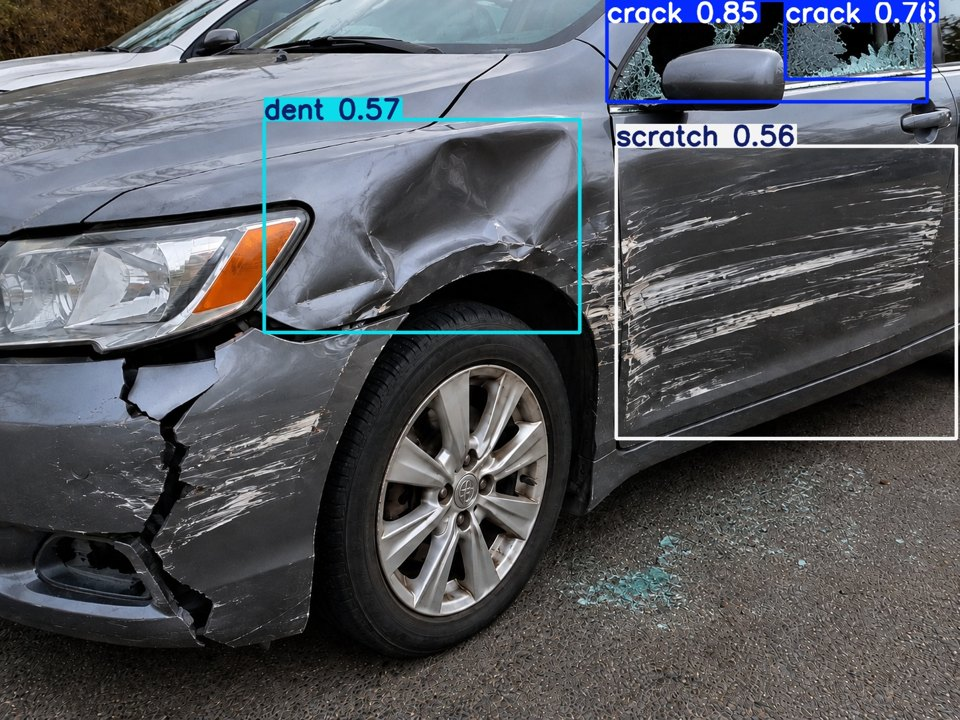

Immagine,Identificativo,Rilevamenti,Report HTML,Cartella output
"ChatGPT Image 2 lug 2026, 17_24_36.png",7344a94aa0f1,4,"/content/drive/MyDrive/progetto_car_damage_SII_web/analisi_immagini/ChatGPT Image 2 lug 2026, 17_24_36_7344a94aa0f1/report_discorsivo.html","/content/drive/MyDrive/progetto_car_damage_SII_web/analisi_immagini/ChatGPT Image 2 lug 2026, 17_24_36_7344a94aa0f1"


In [13]:
# ============================================================
# 13. Caricamento di una o più immagini
# ============================================================

from google.colab import files

COMPONENTE_PER_CLASSE = {
    "crack": None,
    "dent": None,
    "scratch": None
}

display(HTML("""
<div style="
    max-width:950px;
    padding:20px 22px;
    border:1px solid #bfdbfe;
    border-radius:18px;
    background:linear-gradient(135deg,#eff6ff,#f8fafc);
    font-family:Arial,sans-serif;
    margin:10px 0 18px 0;
">
  <div style="font-size:22px;font-weight:850;color:#1e3a8a">
    Carica le immagini da analizzare
  </div>
  <div style="margin-top:8px;color:#334155;line-height:1.55">
    Per ogni immagine verrà prodotto un report discorsivo con descrizione,
    confronto dei casi simili, raccomandazioni separate per classe,
    fonti consultate e dettagli tecnici espandibili.
  </div>
</div>
"""))

uploaded = files.upload()

if not uploaded:
    raise RuntimeError(
        "Nessuna immagine caricata. Riesegui la cella e seleziona almeno un file."
    )

CARTELLA_UPLOAD = Path(
    "/content/immagini_caricate_univoche"
)
CARTELLA_UPLOAD.mkdir(
    parents=True,
    exist_ok=True
)

risultati_sessione = []

for nome_originale, contenuto in uploaded.items():
    if not contenuto:
        print(f"File vuoto ignorato: {nome_originale}")
        continue

    sha256 = hashlib.sha256(contenuto).hexdigest()
    stem_sicuro, estensione = nome_file_sicuro(
        nome_originale
    )
    nome_univoco = (
        f"{stem_sicuro}_{sha256[:12]}{estensione}"
    )
    image_path = CARTELLA_UPLOAD / nome_univoco
    image_path.write_bytes(contenuto)

    risultato = analizza_immagine_con_sistema_intelligente(
        image_path=image_path,
        modello=loaded_model,
        conf=CONF,
        componente_per_classe=COMPONENTE_PER_CLASSE,
        nome_originale=nome_originale,
        sha256=sha256
    )
    risultati_sessione.append(risultato)

if risultati_sessione:
    righe = []
    for risultato in risultati_sessione:
        righe.append({
            "Immagine": risultato["nome_originale"],
            "Identificativo": risultato["id_immagine"],
            "Rilevamenti": len(risultato["detections"]),
            "Report HTML": str(risultato["report_html"]),
            "Cartella output": str(risultato["cartella_output"])
        })

    riepilogo_sessione = pd.DataFrame(righe)

    display(HTML(f"""
    {CSS_REPORT}
    <div class="cd-page">
      <details class="cd-details" open>
        <summary>Riepilogo dei report prodotti</summary>
        {dataframe_html(riepilogo_sessione)}
      </details>
    </div>
    """))


## Testo aggiornato per il report

L'interfaccia finale non si limita a mostrare tabelle e punteggi. Per ogni immagine viene generato un report discorsivo in italiano, composto da una descrizione generale, una sezione separata per ciascuna tipologia di danno e una conclusione complessiva.

La descrizione generale riassume il numero di rilevamenti, le classi riconosciute, la confidence media, la posizione delle bounding box e gli eventuali componenti indicati dall'utente. Per ogni classe vengono poi spiegati a parole il danno osservato, l'estensione visiva, la posizione e il livello di affidabilità della rilevazione.

La raccomandazione viene accompagnata da una spiegazione del processo di recupero: numero di casi locali e Web consultati, caso maggiormente simile e criteri utilizzati nel ranking. Gli interventi vengono presentati come opzioni supportate dalle evidenze e non come diagnosi certe. Quando i primi punteggi sono vicini, il report segnala che non emerge una soluzione nettamente dominante.

Le fonti Web, le query e i punteggi TF-IDF rimangono disponibili in sezioni espandibili, così da mantenere il risultato leggibile senza perdere la trasparenza tecnica. L'intero output viene inoltre salvato come file HTML nella cartella specifica dell'immagine.

Il sistema ha finalità sperimentali e non sostituisce una diagnosi o un preventivo professionale.
